*********1.Install Libraries*********

In [50]:
import pandas as pd 
import numpy as np 
import PIL
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

*********2.Load Data*********

In [111]:
dataset = tf.keras.utils.image_dataset_from_directory(
    'data',
    image_size =(224,224),
    batch_size = 32,
    shuffle = True
)

Found 4972 files belonging to 24 classes.


In [114]:
dataset_class = dataset.class_names

In [165]:
print(dataset_class)

['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']


*********3.Data Preprocessing*********

In [166]:
#Shape of the image and label
for images,label in dataset.take(1):
    print('Image Shape :',images.shape)
    print('Label Shape :',label.shape)

Image Shape : (32, 224, 224, 3)
Label Shape : (32,)


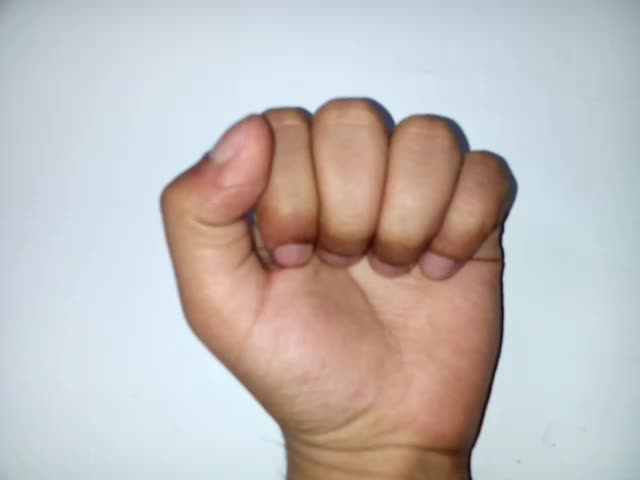

In [54]:
image = PIL.Image.open('data/A/001.jpg')
image

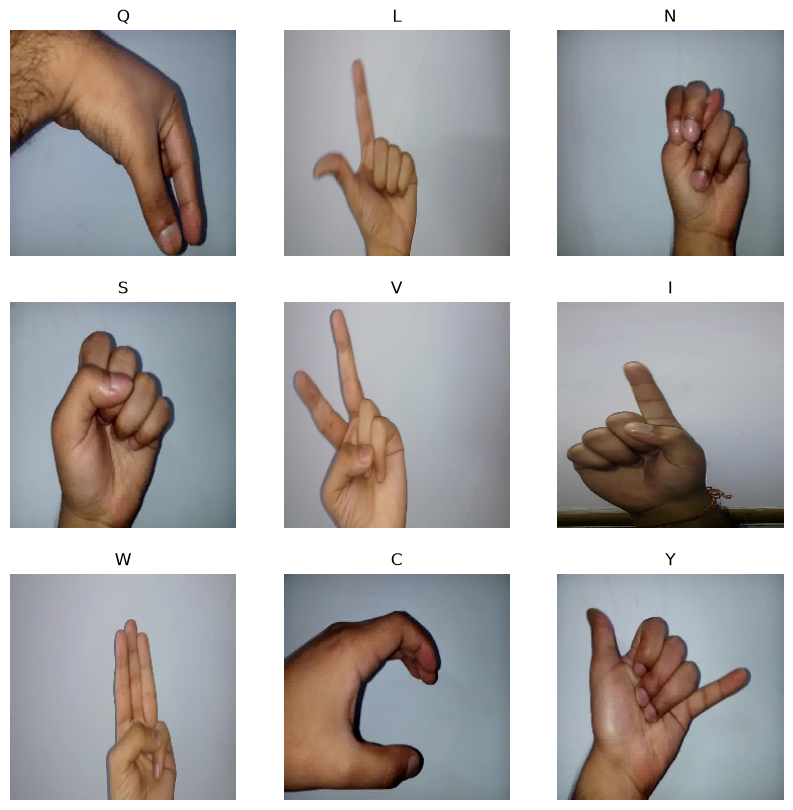

In [55]:
for images,labels in dataset.take(1):
    plt.figure(figsize=(10,10))

    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(dataset.class_names[labels[i]])
        plt.axis('off')

    plt.show()


In [56]:
total_images = len(dataset.file_paths)
print('total_images:',total_images)

num_classes = len(dataset.class_names)
print('total_number_of_class :',num_classes)

total_images: 4972
total_number_of_class : 24


*******4.Counting the Class Values*******

In [57]:
from collections import Counter

count = Counter()

for image,label in dataset:
    count.update(label.numpy())

for class_names,counts in sorted(count.items()):
    print(dataset.class_names[class_names],':',counts)



A : 242
B : 259
C : 247
D : 147
E : 243
F : 226
G : 241
H : 116
I : 179
K : 245
L : 182
M : 235
N : 237
O : 229
P : 234
Q : 216
R : 211
S : 229
T : 216
U : 135
V : 122
W : 128
X : 202
Y : 251


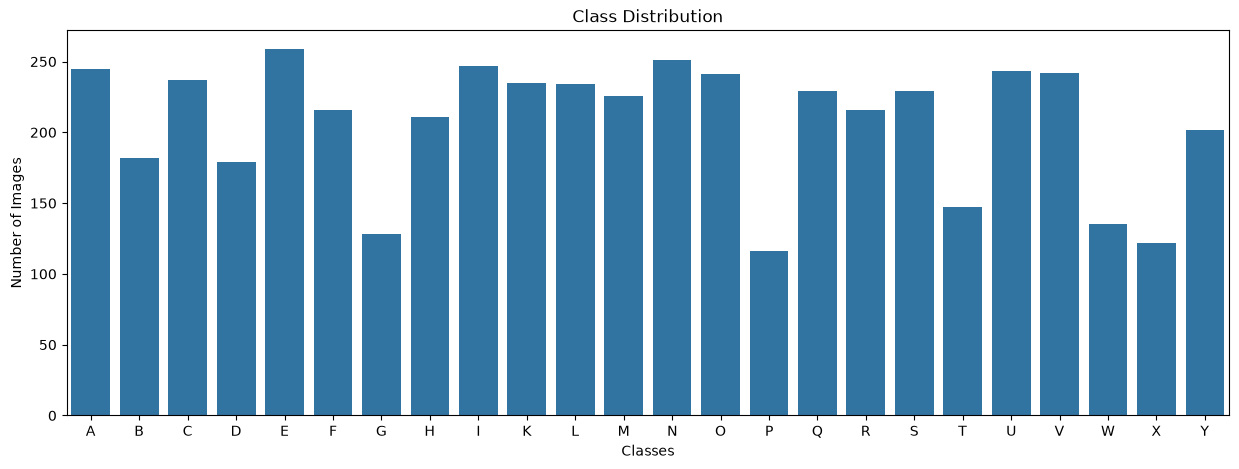

In [58]:
plt.figure(figsize=(15,5))

class_names = dataset.class_names
class_labels = [i for n,i in count.items()]

sns.barplot(x = class_names, y = class_labels)
plt.xlabel('Classes')
plt.ylabel('Number of Images')
plt.title('Class Distribution')
plt.show()


***********Scaling***********

In [176]:
data_iter = dataset.as_numpy_iterator()
batch = data_iter.next()
batch

(array([[[[ 90.      , 101.      , 105.      ],
          [ 90.      , 101.      , 105.      ],
          [ 90.      , 101.      , 105.      ],
          ...,
          [ 98.      , 116.      , 128.      ],
          [ 98.      , 116.      , 128.      ],
          [ 98.      , 116.      , 128.      ]],
 
         [[ 90.      , 101.      , 105.      ],
          [ 90.      , 101.      , 105.      ],
          [ 90.      , 101.      , 105.      ],
          ...,
          [ 98.      , 116.      , 128.      ],
          [ 98.      , 116.      , 128.      ],
          [ 98.      , 116.      , 128.      ]],
 
         [[ 90.      , 101.      , 105.      ],
          [ 90.      , 101.      , 105.      ],
          [ 90.      , 101.      , 105.      ],
          ...,
          [ 98.      , 116.      , 128.      ],
          [ 98.      , 116.      , 128.      ],
          [ 98.      , 116.      , 128.      ]],
 
         ...,
 
         [[ 88.92857 , 101.92857 , 109.92857 ],
          [ 97.357

In [174]:
len(dataset)

156

In [175]:
len(dataset.file_paths)

4972

In [ ]:
dataset = dataset.map(lambda x,y : (x/255,y))

In [70]:
scaled_iter = dataset.as_numpy_iterator()
batch = scaled_iter.next()
print(batch[0].min())
print(batch[0].max())


0.0
1.0


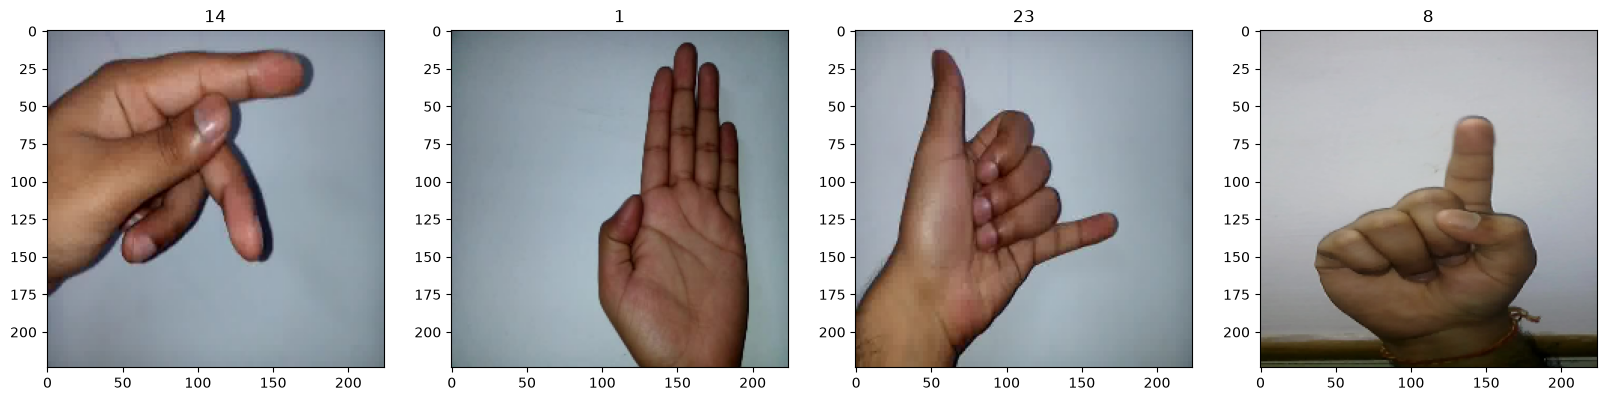

In [71]:
fig, ax = plt.subplots(ncols = 4 , figsize = (20,20))

for ind,img in enumerate(batch[0][:4]):
    ax[ind].imshow(img)
    ax[ind].title.set_text(batch[1][ind])

******Train,Validation and Test Split******

In [72]:
len(dataset)

156

In [73]:
train_size = int(len(dataset)*0.70)
val_size = int(len(dataset)*0.15)
test_size = (len(dataset) - train_size) - val_size

In [74]:
print("The Size of Train Size :",train_size)
print("The Size of Validation Size :",val_size)
print("The Size of Test Size:",test_size)


The Size of Train Size : 109
The Size of Validation Size : 23
The Size of Test Size: 24


In [75]:
train = dataset.take(train_size)
val = dataset.skip(train_size).take(val_size)
test = dataset.skip(train_size + val_size).take(test_size)

******Building CNN******

**Data Augumentation**

In [76]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Dense,Flatten

In [77]:
#Data Augumentation
 
data_augumentation = Sequential([
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomTranslation(0.1,0.1)
])



In [78]:
#CNN

model = Sequential([

    tf.keras.layers.Input(shape=(224,224,3)),

    data_augumentation,

    #Block 1 
    tf.keras.layers.Conv2D(32,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    #Block 2
    tf.keras.layers.Conv2D(64,(3,3),activation=('relu')),
    tf.keras.layers.MaxPooling2D(),

    #Block 3
    tf.keras.layers.Conv2D(128,(3,3),activation=('relu')),
    tf.keras.layers.MaxPooling2D(),


    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128,activation='relu'),

    tf.keras.layers.Dense(num_classes,activation='softmax')
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,172,056 (42.62 MB)

 Trainable params: 11,172,056 (42.62 MB)

 Non-trainable params: 0 (0.00 B)

***Compile***

In [79]:
model.compile(
    optimizer = 'adam',
    loss = tf.losses.sparse_categorical_crossentropy,
    metrics =['accuracy']
)


In [80]:
early_stopping = tf.keras.callbacks.EarlyStopping(patience=3,monitor='val_loss',restore_best_weights=True)


log_dir = 'logs'
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir) 

*******Train the Model*******

In [81]:
hist = model.fit(
    train,
    validation_data = val,
    epochs = 20,
    callbacks = [early_stopping,tensorboard_callback]
)



Epoch 1/20


/mnt/d/Subi/Documents/Internship/Project/AI/indisign/.venv2/lib/python3.14/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
W0000 00:00:1790535816.359977    9722 prefetch_autotuner.cc:56] Prefetch autotuner tried to allocate 37224704 bytes after encountering the first element of size 37224704 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.2752 - loss: 2.4538

W0000 00:00:1790535834.635267    9722 prefetch_autotuner.cc:56] Prefetch autotuner tried to allocate 37224704 bytes after encountering the first element of size 37224704 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


109/109 ━━━━━━━━━━━━━━━━━━━━ 21s 177ms/step - accuracy: 0.2752 - loss: 2.4538 - val_accuracy: 0.6603 - val_loss: 1.1324
Epoch 2/20
  2/109 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - accuracy: 0.4844 - loss: 1.5603 

...

109/109 ━━━━━━━━━━━━━━━━━━━━ 13s 119ms/step - accuracy: 0.9232 - loss: 0.2432 - val_accuracy: 0.9524 - val_loss: 0.1718
Epoch 11/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.9292 - loss: 0.2253

W0000 00:00:1790535964.141674    9722 prefetch_autotuner.cc:56] Prefetch autotuner tried to allocate 37224704 bytes after encountering the first element of size 37224704 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


109/109 ━━━━━━━━━━━━━━━━━━━━ 13s 121ms/step - accuracy: 0.9292 - loss: 0.2253 - val_accuracy: 0.8139 - val_loss: 0.4987
Epoch 12/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.9409 - loss: 0.1775

W0000 00:00:1790535977.349850    9722 prefetch_autotuner.cc:56] Prefetch autotuner tried to allocate 19267840 bytes after encountering the first element of size 19267840 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


109/109 ━━━━━━━━━━━━━━━━━━━━ 13s 121ms/step - accuracy: 0.9409 - loss: 0.1775 - val_accuracy: 0.9538 - val_loss: 0.1009


In [82]:
hist.history

{'accuracy': [0.2752293646335602,
  0.6029242873191833,
  0.7270641922950745,
  0.7855504751205444,
  0.8443233966827393,
  0.889048159122467,
  0.8861811757087708,
  0.9022362232208252,
  0.9122706651687622,
  0.9231651425361633,
  0.9291858077049255,
  0.9409403800964355],
 'loss': [2.4537925720214844,
  1.2841029167175293,
  0.8689915537834167,
  0.6420665383338928,
  0.4924026131629944,
  0.3413724899291992,
  0.347772479057312,
  0.2838493883609772,
  0.2783265709877014,
  0.24323011934757233,
  0.22530975937843323,
  0.17752693593502045],
 'val_accuracy': [0.6603260636329651,
  0.8125,
  0.8491848111152649,
  0.885869562625885,
  0.898097813129425,
  0.8913043737411499,
  0.88722825050354,
  0.9089673757553101,
  0.9850543737411499,
  0.9524456262588501,
  0.813858687877655,
  0.9538043737411499],
 'val_loss': [1.132440447807312,
  0.6246083974838257,
  0.43368929624557495,
  0.3526737689971924,
  0.32249027490615845,
  0.3077632188796997,
  0.3196377456188202,
  0.25801134109497

*******Plot Performence*******

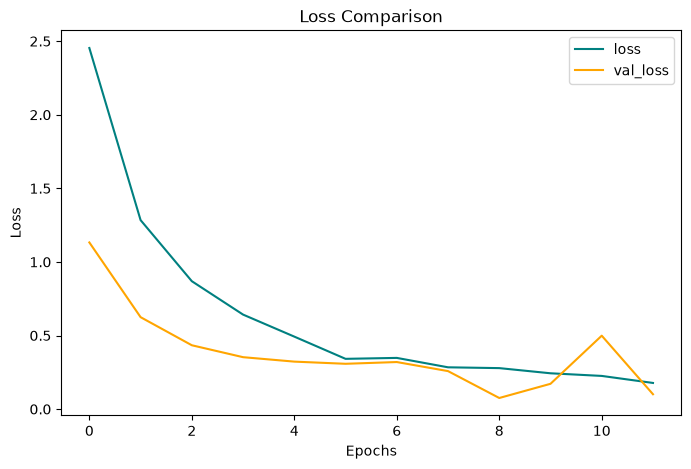

In [83]:
plt.figure(figsize=(8,5))
plt.plot(hist.history['loss'],color = 'teal',label = 'loss')
plt.plot(hist.history['val_loss'],color = 'orange',label = 'val_loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Comparison')
plt.legend()
plt.show()

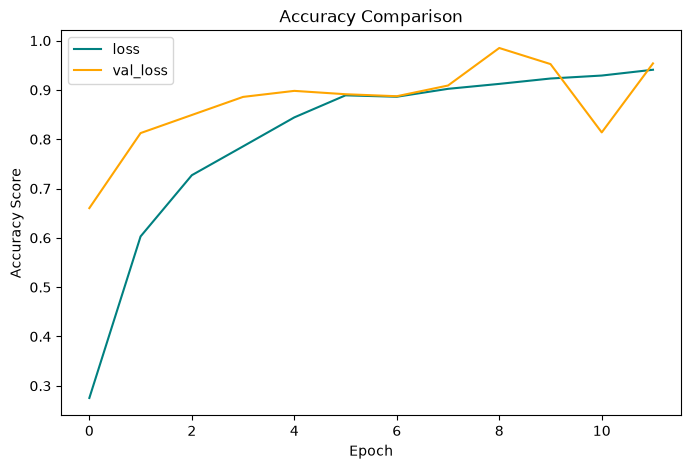

In [84]:
plt.figure(figsize=(8,5))
plt.plot(hist.history['accuracy'],color = 'teal',label = 'loss')
plt.plot(hist.history['val_accuracy'],color = 'orange',label = 'val_loss')
plt.xlabel('Epoch')
plt.ylabel('Accuracy Score')
plt.title('Accuracy Comparison')
plt.legend()
plt.show()

*******Evaluvate*******

In [85]:
from tensorflow.keras.metrics import BinaryAccuracy, Recall, Precision

In [97]:
y_true =[]
y_pred = []


for X,y in test.as_numpy_iterator():
    pred = model.predict(X,verbose=0)
    pred_clas = np.argmax(pred,axis=1)

    y_true.extend(y)
    y_pred.extend(pred_clas)


W0000 00:00:1790536623.224812    9722 prefetch_autotuner.cc:56] Prefetch autotuner tried to allocate 37224704 bytes after encountering the first element of size 37224704 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


In [ ]:
#Changing into numpy array
y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [164]:
from sklearn.metrics import classification_report,confusion_matrix

print(classification_report(y_true,y_pred,target_names=dataset_class))

              precision    recall  f1-score   support

           A       1.00      1.00      1.00        39
           B       0.98      0.96      0.97        48
           C       0.91      1.00      0.96        32
           D       1.00      1.00      1.00        22
           E       1.00      1.00      1.00        40
           F       0.95      1.00      0.97        36
           G       1.00      1.00      1.00        40
           H       1.00      1.00      1.00        16
           I       1.00      1.00      1.00        26
           K       0.97      1.00      0.99        38
           L       0.93      1.00      0.96        27
           M       1.00      1.00      1.00        29
           N       0.94      0.97      0.96        35
           O       1.00      0.94      0.97        36
           P       0.96      1.00      0.98        23
           Q       1.00      0.97      0.99        36
           R       1.00      0.97      0.99        34
           S       1.00    

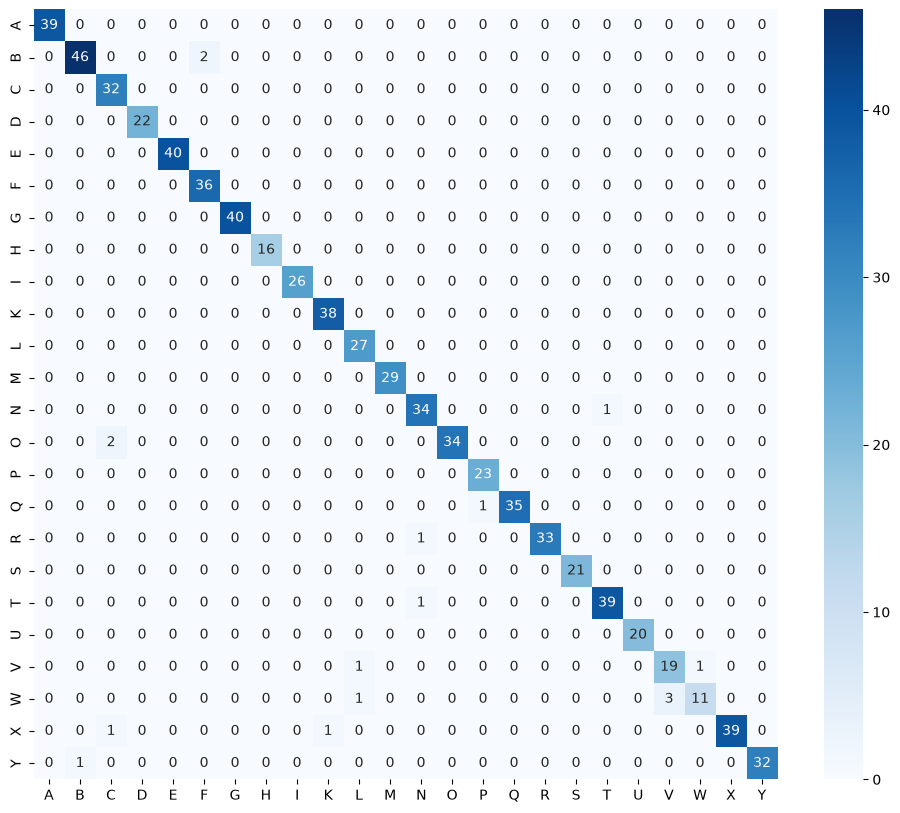

In [120]:
cm = confusion_matrix(y_true,y_pred)

plt.figure(figsize=(12,10))

sns.heatmap(cm,fmt='d',annot=True,cmap='Blues',xticklabels=dataset_class,yticklabels=dataset_class)

plt.show()

*********Prediction System*********

In [160]:
def prediction_system(image_path):
    img = cv2.imread(image_path)

    if img is None:
        print('Image Not found,',image_path)
        return

    img_rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    img_resized = cv2.resize(img_rgb,(224,224))

    img_batch = np.expand_dims(img_resized,axis=0)

    prediction = model.predict(img_batch,verbose=0)

    pred_index =np.argmax(prediction[0])

    print(prediction[0])
    confidence = prediction[0][pred_index]* 100

    class_name = dataset_class[pred_index]

    plt.figure(figsize=(5,5))
    plt.imshow(img_rgb)
    plt.title(f'Prediction :{class_name}\n'f'Confidence :{confidence:.2f}%')

    plt.axis('off')
    plt.show()

    return confidence,pred_clas

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


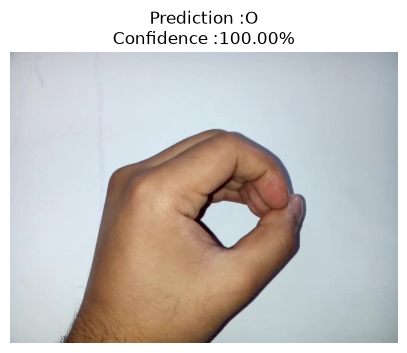

(np.float32(100.0), array([ 1, 14, 16,  7,  9,  4, 10, 16,  0,  9, 23, 11]))

In [161]:
prediction_system('/mnt/d/Subi/Documents/Internship/Project/AI/indisign/data/O/003.jpg')

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


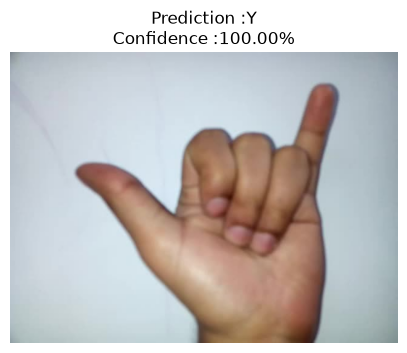

(np.float32(100.0), array([ 1, 14, 16,  7,  9,  4, 10, 16,  0,  9, 23, 11]))

In [162]:
prediction_system('/mnt/d/Subi/Documents/Internship/Project/AI/indisign/data/Y/002.jpg')

********Save The Model**********